In [25]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import statistics as sts 
import joblib
import streamlit as st 
import traceback
from sklearn.preprocessing import StandardScaler,PowerTransformer,LabelEncoder,OrdinalEncoder
from sklearn.metrics import precision_score,accuracy_score,f1_score,classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score,GridSearchCV,train_test_split
from sklearn.impute import SimpleImputer

In [26]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\crime_data.csv",encoding_errors='ignore')

In [27]:
df2=df1.copy()

In [28]:
def Basic_checks(df2):
    print(df2.ndim)
    print(df2.shape)
    print(df2.size)
    print(df2.describe())
    print(df2.info())
    
Basic_checks(df2)

2
(6638, 12)
79656
       Offender_Age   Victim_Age
count   6638.000000  6638.000000
mean      34.634378    38.590539
std       12.797407    15.297202
min       11.000000     0.000000
25%       25.000000    27.000000
50%       33.000000    36.000000
75%       42.000000    48.000000
max       83.000000   124.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6638 entries, 0 to 6637
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Disposition          6638 non-null   object 
 1   OffenderStatus       6638 non-null   object 
 2   Offender_Race        6638 non-null   object 
 3   Offender_Gender      6638 non-null   object 
 4   Offender_Age         6638 non-null   float64
 5   PersonType           6638 non-null   object 
 6   Victim_Race          6638 non-null   object 
 7   Victim_Gender        6638 non-null   object 
 8   Victim_Age           6638 non-null   float64
 9   Victim_Fatal_Status  6

In [29]:
df2.drop_duplicates(inplace=True)


In [30]:
df2.isna().sum()

Disposition            0
OffenderStatus         0
Offender_Race          0
Offender_Gender        0
Offender_Age           0
PersonType             0
Victim_Race            0
Victim_Gender          0
Victim_Age             0
Victim_Fatal_Status    0
Report Type            0
Category               0
dtype: int64

In [31]:
df2.isnull().sum()

Disposition            0
OffenderStatus         0
Offender_Race          0
Offender_Gender        0
Offender_Age           0
PersonType             0
Victim_Race            0
Victim_Gender          0
Victim_Age             0
Victim_Fatal_Status    0
Report Type            0
Category               0
dtype: int64

In [32]:
df2.dropna(how='any',axis=0,inplace=True)

In [33]:
df2.sample(1)

,Disposition,OffenderStatus,Offender_Race,Offender_Gender,Offender_Age,PersonType,Victim_Race,Victim_Gender,Victim_Age,Victim_Fatal_Status,Report Type,Category
3950,CLOSED,ARRESTED,BLACK,FEMALE,28.0,VICTIM,BLACK,MALE,40.0,Non-fatal,Incident Report,Violence


In [34]:
df2.columns

Index(['Disposition', 'OffenderStatus', 'Offender_Race', 'Offender_Gender',
       'Offender_Age', 'PersonType', 'Victim_Race', 'Victim_Gender',
       'Victim_Age', 'Victim_Fatal_Status', 'Report Type', 'Category'],
      dtype='object')

In [35]:
label_encoder=LabelEncoder()
df2['category_encoded']=label_encoder.fit_transform(df2['Category'])

In [36]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4694 entries, 0 to 6637
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Disposition          4694 non-null   object 
 1   OffenderStatus       4694 non-null   object 
 2   Offender_Race        4694 non-null   object 
 3   Offender_Gender      4694 non-null   object 
 4   Offender_Age         4694 non-null   float64
 5   PersonType           4694 non-null   object 
 6   Victim_Race          4694 non-null   object 
 7   Victim_Gender        4694 non-null   object 
 8   Victim_Age           4694 non-null   float64
 9   Victim_Fatal_Status  4694 non-null   object 
 10  Report Type          4694 non-null   object 
 11  Category             4694 non-null   object 
 12  category_encoded     4694 non-null   int64  
dtypes: float64(2), int64(1), object(10)
memory usage: 513.4+ KB


In [37]:
new_cols=['Disposition_encoded', 'OffenderStatus_encoded', 'Offender_Race_encoded', 'Offender_Gender_encoded', 'PersonType_encoded', 'Victim_Race_encoded', 'Victim_Gender_encoded',
        'Victim_Fatal_Status_encoded', 'Report_Type_encoded']
old_cols=['Disposition', 'OffenderStatus', 'Offender_Race', 'Offender_Gender',
        'PersonType', 'Victim_Race', 'Victim_Gender', 'Victim_Fatal_Status', 'Report Type']


df2[new_cols]=df2[old_cols].apply(label_encoder.fit_transform)

In [38]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4694 entries, 0 to 6637
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Disposition                  4694 non-null   object 
 1   OffenderStatus               4694 non-null   object 
 2   Offender_Race                4694 non-null   object 
 3   Offender_Gender              4694 non-null   object 
 4   Offender_Age                 4694 non-null   float64
 5   PersonType                   4694 non-null   object 
 6   Victim_Race                  4694 non-null   object 
 7   Victim_Gender                4694 non-null   object 
 8   Victim_Age                   4694 non-null   float64
 9   Victim_Fatal_Status          4694 non-null   object 
 10  Report Type                  4694 non-null   object 
 11  Category                     4694 non-null   object 
 12  category_encoded             4694 non-null   int64  
 13  Disposition_encoded    

In [39]:
df2.sample(2)

,Disposition,OffenderStatus,Offender_Race,Offender_Gender,Offender_Age,PersonType,Victim_Race,Victim_Gender,Victim_Age,Victim_Fatal_Status,...,category_encoded,Disposition_encoded,OffenderStatus_encoded,Offender_Race_encoded,Offender_Gender_encoded,PersonType_encoded,Victim_Race_encoded,Victim_Gender_encoded,Victim_Fatal_Status_encoded,Report_Type_encoded
6008,CLOSED,ARRESTED,BLACK,MALE,38.0,VICTIM,WHITE,FEMALE,30.0,Non-fatal,...,5,0,0,2,1,2,5,0,1,0
5390,CLOSED,ARRESTED,BLACK,MALE,36.0,VICTIM,BLACK,MALE,35.0,Non-fatal,...,1,0,0,2,1,2,2,1,1,0


In [40]:
df2[['category_encoded','Category']]

,category_encoded,Category
0,3,Theft
5,1,Miscellaneous
6,1,Miscellaneous
7,1,Miscellaneous
9,4,Vandalism
...,...,...
6632,3,Theft
6634,3,Theft
6635,5,Violence
6636,5,Violence


In [41]:
df3=df2.copy()

In [42]:
cata_cols=df3.select_dtypes(include='object').columns
print(cata_cols)

Index(['Disposition', 'OffenderStatus', 'Offender_Race', 'Offender_Gender',
       'PersonType', 'Victim_Race', 'Victim_Gender', 'Victim_Fatal_Status',
       'Report Type', 'Category'],
      dtype='object')


In [43]:
df3.drop(columns=['Disposition', 'OffenderStatus', 'Offender_Race', 'Offender_Gender'] ,axis=1,inplace=True)

In [44]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4694 entries, 0 to 6637
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Offender_Age                 4694 non-null   float64
 1   PersonType                   4694 non-null   object 
 2   Victim_Race                  4694 non-null   object 
 3   Victim_Gender                4694 non-null   object 
 4   Victim_Age                   4694 non-null   float64
 5   Victim_Fatal_Status          4694 non-null   object 
 6   Report Type                  4694 non-null   object 
 7   Category                     4694 non-null   object 
 8   category_encoded             4694 non-null   int64  
 9   Disposition_encoded          4694 non-null   int64  
 10  OffenderStatus_encoded       4694 non-null   int64  
 11  Offender_Race_encoded        4694 non-null   int64  
 12  Offender_Gender_encoded      4694 non-null   int64  
 13  PersonType_encoded     

In [45]:
df3.columns

Index(['Offender_Age', 'PersonType', 'Victim_Race', 'Victim_Gender',
       'Victim_Age', 'Victim_Fatal_Status', 'Report Type', 'Category',
       'category_encoded', 'Disposition_encoded', 'OffenderStatus_encoded',
       'Offender_Race_encoded', 'Offender_Gender_encoded',
       'PersonType_encoded', 'Victim_Race_encoded', 'Victim_Gender_encoded',
       'Victim_Fatal_Status_encoded', 'Report_Type_encoded'],
      dtype='object')

In [46]:
df3=pd.DataFrame(data=df3,columns=['Offender_Age', 'Victim_Age', 'Disposition_encoded',
       'OffenderStatus_encoded', 'Offender_Race_encoded',
       'Offender_Gender_encoded', 'PersonType_encoded', 'Victim_Race_encoded',
       'Victim_Gender_encoded', 'Victim_Fatal_Status_encoded',
       'Report_Type_encoded','category_encoded'],dtype=int)

In [47]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4694 entries, 0 to 6637
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Offender_Age                 4694 non-null   int64
 1   Victim_Age                   4694 non-null   int64
 2   Disposition_encoded          4694 non-null   int64
 3   OffenderStatus_encoded       4694 non-null   int64
 4   Offender_Race_encoded        4694 non-null   int64
 5   Offender_Gender_encoded      4694 non-null   int64
 6   PersonType_encoded           4694 non-null   int64
 7   Victim_Race_encoded          4694 non-null   int64
 8   Victim_Gender_encoded        4694 non-null   int64
 9   Victim_Fatal_Status_encoded  4694 non-null   int64
 10  Report_Type_encoded          4694 non-null   int64
 11  category_encoded             4694 non-null   int64
dtypes: int64(12)
memory usage: 476.7 KB


In [50]:
df3.sample(10)

,Offender_Age,Victim_Age,Disposition_encoded,OffenderStatus_encoded,Offender_Race_encoded,Offender_Gender_encoded,PersonType_encoded,Victim_Race_encoded,Victim_Gender_encoded,Victim_Fatal_Status_encoded,Report_Type_encoded,category_encoded
5845,27,22,1,0,2,1,2,2,0,1,0,5
520,36,42,0,0,5,0,2,5,1,1,1,3
2555,42,66,0,0,4,1,2,5,0,1,1,3
1506,20,33,1,0,2,0,2,2,0,1,0,1
1398,39,35,0,0,2,1,2,2,0,1,1,5
1611,60,28,0,0,2,1,2,2,0,1,0,5
717,18,47,0,0,2,1,2,2,0,1,0,5
955,59,78,1,0,2,0,2,2,1,1,0,1
285,47,48,0,0,2,1,2,2,1,1,1,5
1131,31,42,0,0,2,0,2,2,1,1,0,5


In [52]:
df3.drop(columns=['OffenderStatus_encoded'],axis=1,inplace=True)

In [58]:
spearman1=df3.corr(method='spearman').round(2)

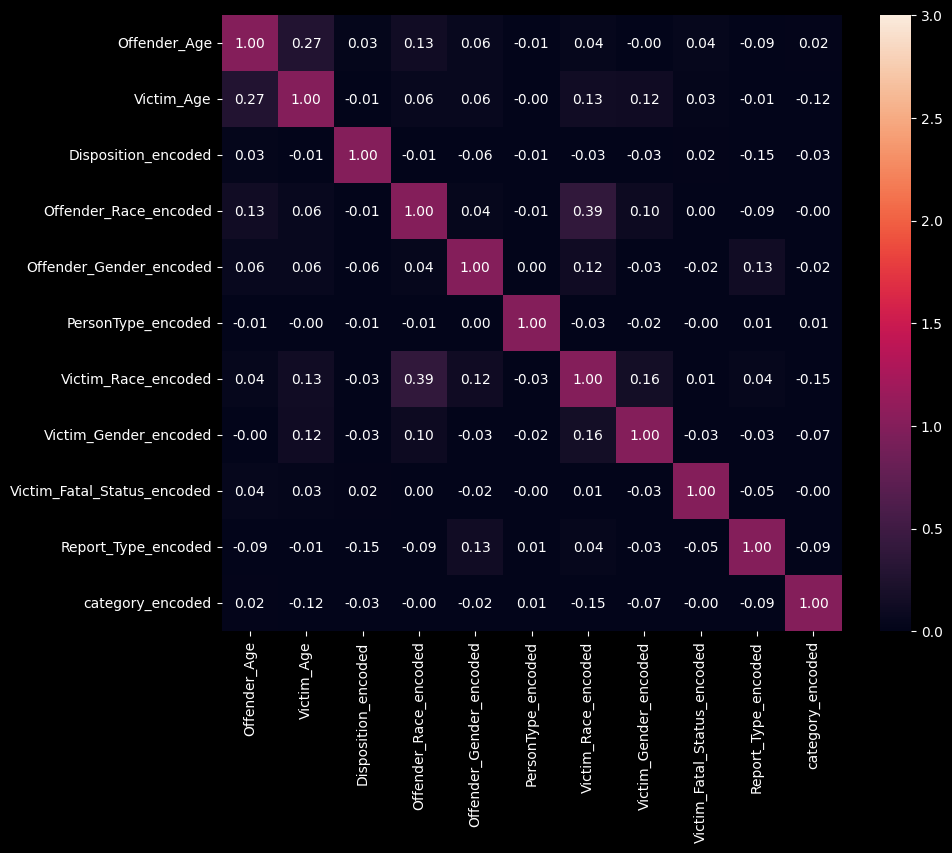

In [62]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(spearman1,annot=True,fmt=".2f",cbar=True,vmin=0,vmax=3)
plt.show()

In [56]:
pearson=df3.corr(method='pearson').round(2)
pearson

,Offender_Age,Victim_Age,Disposition_encoded,Offender_Race_encoded,Offender_Gender_encoded,PersonType_encoded,Victim_Race_encoded,Victim_Gender_encoded,Victim_Fatal_Status_encoded,Report_Type_encoded,category_encoded
Offender_Age,1.00,0.26,0.04,0.12,0.07,-0.00,0.04,-0.01,0.04,-0.09,-0.01
Victim_Age,0.26,1.00,-0.01,0.06,0.05,-0.00,0.13,0.11,0.02,-0.01,-0.11
Disposition_encoded,0.04,-0.01,1.00,-0.01,-0.06,-0.01,-0.03,-0.03,0.02,-0.15,-0.04
Offender_Race_encoded,0.12,0.06,-0.01,1.00,0.04,-0.01,0.39,0.10,0.00,-0.09,-0.01
Offender_Gender_encoded,0.07,0.05,-0.06,0.04,1.00,0.00,0.12,-0.03,-0.02,0.13,-0.01
PersonType_encoded,-0.00,-0.00,-0.01,-0.01,0.00,1.00,-0.03,-0.02,-0.00,0.01,0.00
Victim_Race_encoded,0.04,0.13,-0.03,0.39,0.12,-0.03,1.00,0.16,0.01,0.04,-0.12
Victim_Gender_encoded,-0.01,0.11,-0.03,0.10,-0.03,-0.02,0.16,1.00,-0.03,-0.03,-0.06
Victim_Fatal_Status_encoded,0.04,0.02,0.02,0.00,-0.02,-0.00,0.01,-0.03,1.00,-0.05,0.01
Report_Type_encoded,-0.09,-0.01,-0.15,-0.09,0.13,0.01,0.04,-0.03,-0.05,1.00,-0.05


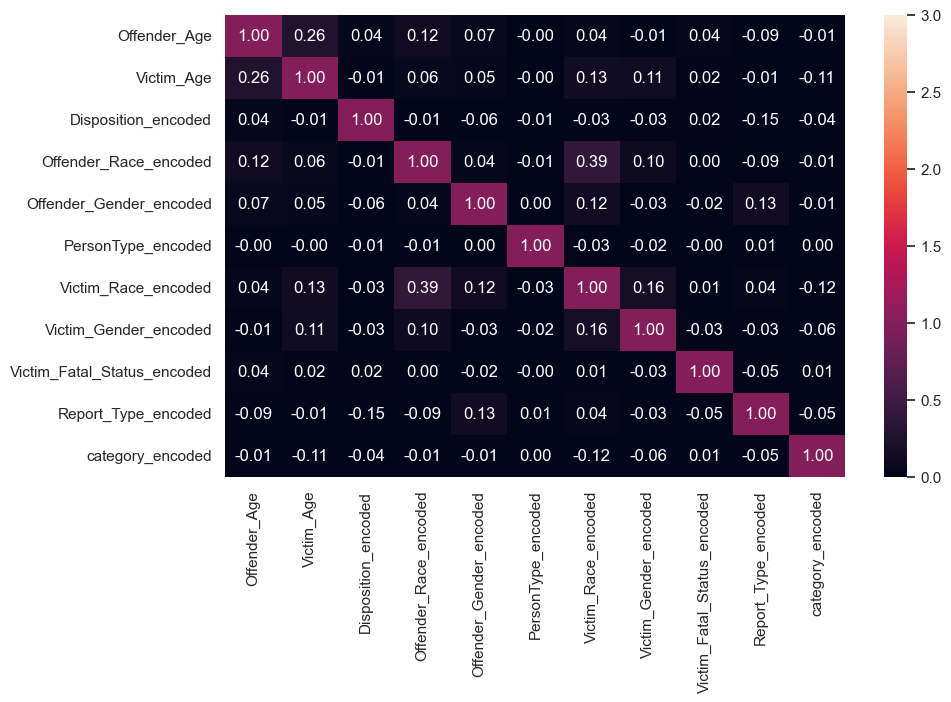

In [68]:
plt.figure(figsize=(10,6))

sns.set_theme(style='whitegrid')
sns.heatmap(pearson,annot=True,fmt=".2f",cbar=True,vmin=0,vmax=3)
plt.show()

In [69]:
df3.columns

Index(['Offender_Age', 'Victim_Age', 'Disposition_encoded',
       'Offender_Race_encoded', 'Offender_Gender_encoded',
       'PersonType_encoded', 'Victim_Race_encoded', 'Victim_Gender_encoded',
       'Victim_Fatal_Status_encoded', 'Report_Type_encoded',
       'category_encoded'],
      dtype='object')

In [70]:
df3.head(10)

,Offender_Age,Victim_Age,Disposition_encoded,Offender_Race_encoded,Offender_Gender_encoded,PersonType_encoded,Victim_Race_encoded,Victim_Gender_encoded,Victim_Fatal_Status_encoded,Report_Type_encoded,category_encoded
0,30,29,0,2,1,2,2,0,1,1,3
5,27,62,0,3,1,2,5,0,1,0,1
6,27,39,0,3,1,2,5,1,1,0,1
7,27,50,0,3,1,2,5,1,1,0,1
9,22,27,0,2,0,2,2,0,1,0,4
10,23,46,0,5,0,2,5,0,1,0,5
11,49,53,0,2,1,2,2,0,1,0,1
12,27,36,0,2,0,2,2,0,1,1,5
13,25,28,0,2,1,2,5,0,1,1,3
14,24,28,0,2,0,2,5,0,1,1,3


In [71]:
df3.isna().sum()

Offender_Age                   0
Victim_Age                     0
Disposition_encoded            0
Offender_Race_encoded          0
Offender_Gender_encoded        0
PersonType_encoded             0
Victim_Race_encoded            0
Victim_Gender_encoded          0
Victim_Fatal_Status_encoded    0
Report_Type_encoded            0
category_encoded               0
dtype: int64

In [72]:
df3.isnull().sum()

Offender_Age                   0
Victim_Age                     0
Disposition_encoded            0
Offender_Race_encoded          0
Offender_Gender_encoded        0
PersonType_encoded             0
Victim_Race_encoded            0
Victim_Gender_encoded          0
Victim_Fatal_Status_encoded    0
Report_Type_encoded            0
category_encoded               0
dtype: int64

In [73]:
df3.columns

Index(['Offender_Age', 'Victim_Age', 'Disposition_encoded',
       'Offender_Race_encoded', 'Offender_Gender_encoded',
       'PersonType_encoded', 'Victim_Race_encoded', 'Victim_Gender_encoded',
       'Victim_Fatal_Status_encoded', 'Report_Type_encoded',
       'category_encoded'],
      dtype='object')

In [74]:
x=df3.iloc[:,:-1]
y=df3.iloc[:,-1]

In [ ]:
random_classifier=RandomForestClassifier(n_estimators=10,n_jobs=-1,criterion='gini',max_depth=10,min_samples_split=[2,5,10,15,20,25,30,35,40,45,50],min_samples_leaf=4,max_features='sqrt')

random_classifier

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.","[2, 5, ...]"
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signatur

In [ ]:

param_grids={'criterion':['gini','entropy','log_loss'],'min_samples_split':[5,10,20,40,50,100],'max_depth':[2,4,6,8,10,12]}
grid_search=GridSearchCV(estimator=random_classifier,param_grid=param_grids,n_jobs=-1,scoring='accuracy')